[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/051_gans/gans.ipynb)

# GANs

GANs (*generative adversarial networks*) es una arquitectura de red neuronal propuesta en 2014 por [Ian Goodfellow](https://arxiv.org/pdf/1406.2661.pdf) y otros con el objetivo de obtener modelos capaces de generar datos realistas, principalmente imágenes. Pese a la simplicidad de la idea original, se tardó varios años en superar varias de las dificultades que presenta su entrenamiento. Hoy en día, sin embargo, se utilizan para obtener resultados espectaculares. Algunos ejemplos son:

- Generación de caras: https://www.thispersondoesnotexist.com/
- Generación de anuncios de Airbnb: https://thisrentaldoesnotexist.com/
- Super-resolución: https://www.youtube.com/watch?v=3RYNThid23g
- Colorización: https://github.com/jantic/DeOldify
- Generación de paisajes: http://nvidia-research-mingyuliu.com/gaugan
- Y muchos otros.

## La arquitectura

La arquitectura básica de las *GANs* está formada por dos redes neuronales:

- El **generador**: recibe a la entrada valores aleatorios (normalmente obtenidos de una distribución de tipo gausiana) y da a la salida una imagen. Puedes ver la entrada aleatoria como una representación latente (o codificación) de la imagen generada.
- El **discriminador**: recibe a la entrada una imagen (real o generada por el generador) y tiene que decidir si bien la imagen es real o falsa.

![](https://www.researchgate.net/publication/336781462/figure/fig2/AS:817722363494401@1571971612898/Example-of-a-typical-GANs-architecture-for-both-hand-written-digits-recognition-and.png)

Durante el entrenamiento, el generador y el discriminador compiten entre ellos. Por un lado, el generador intenta generar imágenes cada vez más realistas para poder engañar al discriminador. Por otro lado, el discriminador cada vez será más bueno diferenciando imágenes reales de las generadas artificialmente por el generador. Esto implica que no podemos entrenar una *GAN* como hemos entrenado el resto de redes neuronales. El objetivo final será el de obtener un generador tan bueno que nuestro discriminador no sea capaz de diferenciar imágenes reales de falsas. Ésto impone unas restricciones muy fuertes en el proceso de entrenamiento, haciendo que sea difícil si no lo hacemos de la forma adecuada.

## El entrenamiento

Para poder entrenar una *GAN* de manera efectiva, lo haremos en dos pasos:

1. En una primera fase, entrenamos el discriminador. En cada iteración, le daremos un *batch* compuesto de imágenes reales obtenidas del dataset e imágenes falsas generadas por el generador. Definiremos un conjunto de etiquetas a 0 para las imágenes falsas y 1 para las reales. Entonces, optimizaremos el discriminador (utilizando una función de pérdida de tipo *binary cross-entropy* mejorando así sus capacidades de distinguir imágenes falsas de reales.
2. En la segunda fase, entrenamos el generador. En cada iteración, le daremos un *batch* compuesto de ruido aleatorio para que genere imágenes. Estas imágenes son introducidas en el discriminador, cuyas salidas (etiquetas real/falso) con comparadas con un conjunto de etiquetas definidas como reales. Entonces, optimizaremos el generador (utilizando de nuevo la misma función de pérdida) de manera que el generador actualizará sus pesos para generar imágenes que engañen al discriminador.

> 💡 Como puedes observar, el generador nunca llega a ver las imágenes reales. Sin embargo es capaz de generar imágenes realistas simplemente intentando engañar al discriminador. Cuánto mejor sea el discriminador, mejor será el generador.

In [54]:
import os
import cv2
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Definir clases y carpetas
dataset_folder = r"E:\Universidad\Ciencias de la computacion\2025-1\sis421\Dataset-Jancko Gallardo Pablo Alejandro"
clases = ["camelia", "corona de cristo", "flor de ruda", "jazmin", "petunia"]
img_size = (128, 128)  # Tamaño uniforme

# Transformaciones de imagen
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Crear dataset personalizado
class FlowerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((img_size[1], img_size[0], 3), dtype=np.uint8)  # Imagen negra si falla
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, label

# Obtener rutas de imágenes y etiquetas
image_paths = []
labels = []

for label, clase in enumerate(clases):
    folder_path = os.path.join(dataset_folder, clase)
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith((".jpg", ".png")):
            img_path = os.path.join(folder_path, filename)
            image_paths.append(img_path)
            labels.append(label)

# Dividir en entrenamiento y prueba
train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.2, random_state=42)

# Crear datasets
train_dataset = FlowerDataset(train_paths, train_labels, transform=transform)
test_dataset = FlowerDataset(test_paths, test_labels, transform=transform)

In [55]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

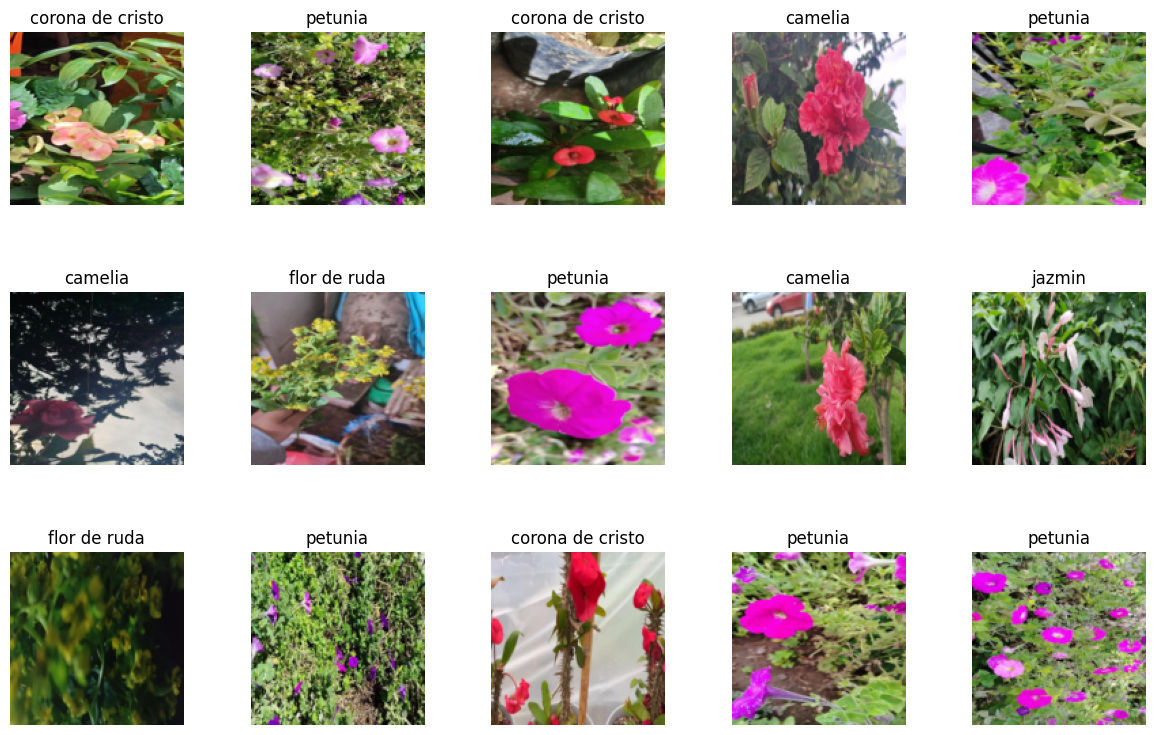

In [40]:
r, c = 3, 5  # Filas y columnas
plt.figure(figsize=(c*3, r*3))

for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)

        ix = random.randint(0, len(train_dataset) - 1)
        img, label = train_dataset[ix]

        img = img.permute(1, 2, 0).numpy()  # Convertir tensor a formato visualizable
        plt.imshow(img)
        plt.axis('off')
        plt.title(clases[label])  # Nombre de la flor

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3300863..0.34384382].


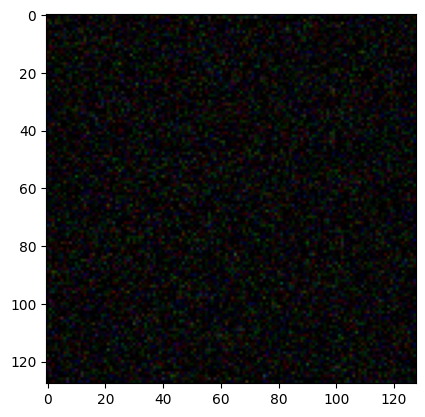

In [43]:
plt.imshow(output[0].reshape(128,128,3).detach().numpy())
plt.show()

El discriminador, por otro lado, recibirá a la entrada una imagen (28 x 28 valores) y a la salida nos dará una clasificación binaria (real o falso).

La siguiente función será la responsable de entrenar ambas redes.

In [70]:
import torch
import os
import numpy as np
import copy
from torch import nn
from tqdm.auto import tqdm  # Para notebook o consola

def fit(g, d, dataloader, epochs=30, crit=None, patience=5, 
        checkpoint_dir='checkpoints', checkpoint_freq=5, device='cuda'):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    g.to(device)
    d.to(device)

    g_optimizer = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5, 0.999))

    real_label = 0.9
    fake_label = 0.1
    
    crit = nn.BCEWithLogitsLoss() if crit is None else crit

    hist = {'g_loss': [], 'd_loss': [], 'real_score': [], 'fake_score': []}
    
    best_g_loss = float('inf')
    best_models = {'g': None, 'd': None}
    patience_counter = 0

    for epoch in tqdm(range(1, epochs + 1), desc="Epochs"):
        g.train()
        d.train()
        
        epoch_g_loss, epoch_d_loss = [], []
        real_scores, fake_scores = [], []

        for X, _ in tqdm(dataloader, desc=f"Epoch {epoch}", leave=False):
            X = X.to(device)
            batch_size = X.size(0)

            # ======== Discriminador ========
            d_optimizer.zero_grad()
            
            real_pred = d(X)
            real_loss = crit(real_pred, torch.full((batch_size, 1), real_label, device=device))
            
            noise = torch.randn(batch_size, g.latent_dim, device=device)
            fake_imgs = g(noise).detach()
            fake_pred = d(fake_imgs)
            fake_loss = crit(fake_pred, torch.full((batch_size, 1), fake_label, device=device))
            
            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()
            
            torch.nn.utils.clip_grad_norm_(d.parameters(), max_norm=1.0)

            # ======== Generador ========
            g_optimizer.zero_grad()
            noise = torch.randn(batch_size, g.latent_dim, device=device)
            gen_imgs = g(noise)
            g_pred = d(gen_imgs)
            g_loss = crit(g_pred, torch.full((batch_size, 1), real_label, device=device))
            
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss.append(d_loss.item())
            epoch_g_loss.append(g_loss.item())
            real_scores.append(torch.sigmoid(real_pred).mean().item())
            fake_scores.append(torch.sigmoid(fake_pred).mean().item())

        # Guardar métricas
        hist['g_loss'].append(np.mean(epoch_g_loss))
        hist['d_loss'].append(np.mean(epoch_d_loss))
        hist['real_score'].append(np.mean(real_scores))
        hist['fake_score'].append(np.mean(fake_scores))

        # Checkpoint
        if epoch % checkpoint_freq == 0:
            torch.save({
                'epoch': epoch,
                'generator': g.state_dict(),
                'discriminator': d.state_dict(),
                'g_optimizer': g_optimizer.state_dict(),
                'd_optimizer': d_optimizer.state_dict(),
                'metrics': hist
            }, f"{checkpoint_dir}/checkpoint_epoch_{epoch}.pt")

        # Early stopping
        current_g_loss = hist['g_loss'][-1]
        if current_g_loss < best_g_loss:
            best_g_loss = current_g_loss
            best_models['g'] = copy.deepcopy(g.state_dict())
            best_models['d'] = copy.deepcopy(d.state_dict())
            patience_counter = 0
            torch.save(best_models, f"{checkpoint_dir}/best_models.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping en época {epoch}")
                break

    g.load_state_dict(best_models['g'])
    d.load_state_dict(best_models['d'])
    
    return hist


e:\Universidad\Ciencias de la computacion\2025-1\sis421\Repositorio\my-venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## DCGANs

Podemos usar *DCGANs* (*deep convolutional GANs*) para obtener mejores generadores utilizando redes convolucionales. En este caso, necesitaremos arquitecturas diferentes para generador y discriminador.

![](https://gluon.mxnet.io/_images/dcgan.png)

El generador recibirá un vector de 100 valores aleatorios y después aplicaremos varias capas de convoluciones transpuestas (que aumentarán el tamaño de los mapas de caracterísitcas, como hicimos en nuestras redes para [segmentación](https://sensioai.com/blog/50_cv_segmentacion)) hasta obtener la imagen generada.

In [3]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim

        self.inp = nn.Sequential(
            nn.Linear(latent_dim, 8 * 8 * 512),  # semilla inicial 8x8
            nn.BatchNorm1d(8 * 8 * 512),
            nn.ReLU(True),
        )

        self.main = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),  # 8x8 → 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 16x16 → 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 32x32 → 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),     # 64x64 → 128x128
            nn.Tanh()  # Salida entre [-1, 1]
        )

    def forward(self, x):
        x = self.inp(x)
        x = x.view(-1, 512, 8, 8)
        x = self.main(x)
        return x  # Salida: [batch, 3, 128, 128]

In [46]:
generator = Generator()
output = generator(torch.randn(32, 100))
output.shape

torch.Size([32, 3, 128, 128])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99953777..0.99990165].


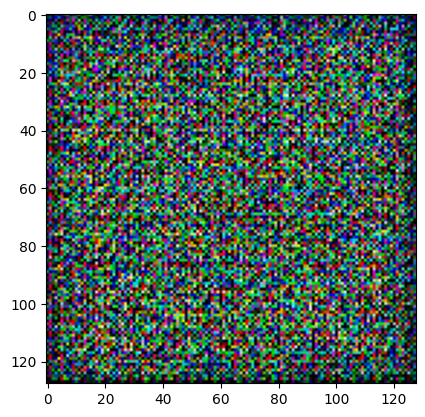

In [47]:
# quiero ver lo que me da el generador
plt.imshow(output[0].permute(1, 2, 0).detach().numpy())
plt.show()

In [4]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),    # 128 → 64
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 64 → 32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 32 → 16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, stride=2, padding=1), # 16 → 8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 8),  # 8x8 → 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.main(x)
        return x.view(-1, 1)  # Salida: [batch_size, 1]


In [51]:
discriminator = Discriminator()
output = discriminator(torch.randn(32, 3, 128, 128))
output.shape

torch.Size([32, 1])

Ahora podemos utilizar exactamente el mismo bucle de entrenamiento anterior para obtener un nuevo generador.

In [71]:
hist = fit(
    generator,
    discriminator,
    train_loader,
    epochs=30,
    patience=4,
    checkpoint_dir='checkpoints',
    checkpoint_freq=5,
    crit=torch.nn.BCELoss()
)


Epochs:  17%|█▋        | 5/30 [7:46:13<38:51:07, 5594.71s/it]


🛑 Early stopping en época 6


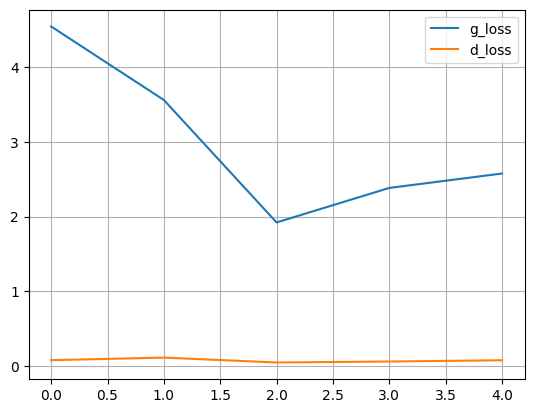

In [64]:
import pandas as pd
df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu126
True


In [5]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Crear una instancia vacía del generador (con misma clase y arquitectura)
generator = Generator().to(device)

# Cargar el checkpoint
checkpoint = torch.load('checkpoints/best_models.pt', map_location=device)

# Cargar los pesos al generador
generator.load_state_dict(checkpoint['g'])

<All keys matched successfully>

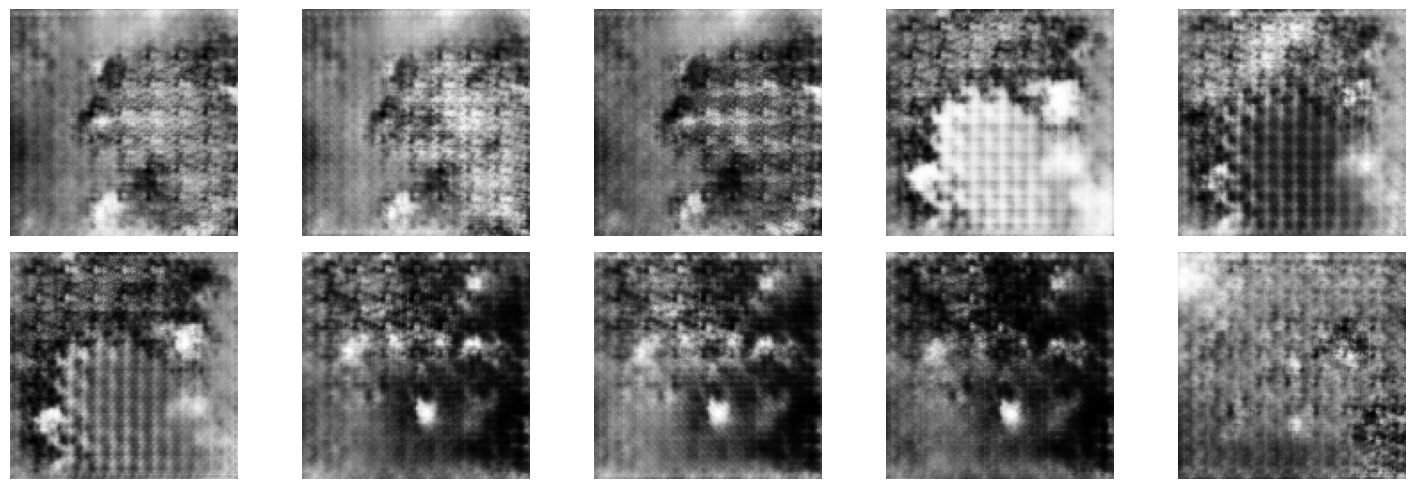

In [7]:
import matplotlib.pyplot as plt
generator.eval()
with torch.no_grad():
    noise = torch.randn((10, generator.latent_dim)).to(device)  # o generator.input_size si usás ese nombre
    generated_images = generator(noise)

    # Si las imágenes están en formato (B, 1, H, W), las pasamos a (H, W)
    generated_images = generated_images.cpu().view(-1, 128, 128)  # cambia 128 si estás usando otra resolución

    fig, axs = plt.subplots(2, 5, figsize=(15, 5))
    i = 0
    for row in axs:
        for ax in row:
            ax.imshow(generated_images[i], cmap="gray")
            ax.axis("off")
            i += 1
    plt.tight_layout()
    plt.show()


## Resumen

En este post hemos aprendido a implementar *GANs*, redes neuronales capaces de generar datos similares a los usados en el entrenamiento, en este caso imágenes. Este tipo de arquitecturas están formadas por dos redes neuronales que compiten entre sí durante el entrenamiento: el generador y el discriminador. El generador se encarga de generar imágenes falsas a partir de un vector de valores aleatorios, que se puede interpretar como una versión comprimida de la imagen, mientras que el discriminador se encarga de distinguir entre imágenes reales, obtenidas del dataset, y falsas, generadas por el generador. Una vez entrenado el modelo, descartamos el discriminador y nos quedamos con el generador que será capaz de generar imágenes realistas, similares a la usadas en el dataset. Este tipo de modelos se utilizan para generar caras de gente que no existe, colorear imágenes en blanco y negro, generar imágenes realistas a partir de máscaras de segmentación, incluso los famosos *deep fakes*.